# Notebook: Data Preprocessing Pipeline and SVM Classification

**DATA5322 — Statistical Machine Learning II**  
Seattle University, Spring 2026  
Team: Ruman Sidhu, Paul Skentzos, Hamda Hassan  
Author: Paul Skentzos

## Project Context

This notebook is part of the Final Project, which applies supervised machine learning to gene expression data from The Cancer Genome Atlas (TCGA). The central research question is:

> Can a computer distinguish cancerous tissue from healthy tissue using gene expression data alone, with no imaging, no biopsy, and no prior diagnosis?

The dataset contains 529 tumor samples and 61 normal breast tissue samples from the BC-TCGA collection. Each sample is described by the expression levels of 5,000 genes selected in earlier preprocessing. The classification task is binary: given the gene expression profile of a tissue sample, predict whether it is tumor (1) or normal (0).

This notebook covers the following portion of the project:

1. Loading and combining tumor and normal samples into a single dataset with binary labels
2. Building the supervised preprocessing pipeline: imputation, standardization, PCA, and train/test split
3. Training a baseline linear SVM to establish a reference point
4. Tuning an RBF SVM using GridSearchCV with 5-fold stratified cross-validation
5. Evaluating the final model with accuracy, weighted F1, confusion matrix, and ROC curve

**Inputs (raw data):**
- `data/BC-TCGA/BC-TCGA-Tumor.txt` — gene expression matrix for 529 tumor samples (17,814 genes x 529 samples)
- `data/BC-TCGA/BC-TCGA-Normal.txt` — gene expression matrix for 61 normal samples (17,814 genes x 61 samples)
- `data/top_genes.csv` — the 5,000 highest-variance genes selected in Notebook 01

**Output:** trained SVM classifier, evaluation metrics, confusion matrix plot, ROC curve plot

## Theoretical Background: Support Vector Machines

### What is a Support Vector Machine?

A Support Vector Machine (SVM) is a supervised learning algorithm that classifies data by finding the best possible boundary, called a hyperplane, between groups. The key idea is not just to find any boundary that separates the classes, but to find the one that maximizes the margin: the gap between the boundary and the nearest data points from each class. Those nearest points are called support vectors, which is where the algorithm gets its name.

Maximizing the margin is important because a wider gap between the decision boundary and the data means the model is less likely to misclassify new, unseen samples. This makes SVMs well-suited to datasets with many features, like gene expression data with thousands of genes, where overfitting is a real risk.

### The Kernel Trick

When data cannot be separated by a straight line or flat plane, SVMs use a mathematical function called a kernel to implicitly map the data into a higher-dimensional space where a flat boundary can work. Two kernels are used in this notebook:

- The linear kernel draws a flat hyperplane as the decision boundary. It is fast to train and interpretable. It works well when the groups are already roughly separable in the original feature space.
- The RBF (Radial Basis Function) kernel, also called the Gaussian kernel, measures similarity between data points based on distance, allowing the SVM to draw curved, non-linear boundaries. It is the most widely used kernel for general classification problems.

### Hyperparameters

Two key parameters control SVM behavior, both tuned in this notebook:

C is the regularization parameter. It controls the trade-off between maximizing the margin and minimizing misclassifications on the training data. A small C allows some misclassifications but produces a wider, more general margin. A large C forces the model to classify all training points correctly, which can lead to a narrow margin and overfitting.

Gamma is the RBF kernel bandwidth parameter. It controls how far the influence of a single training point reaches. A small gamma means each point influences a large neighborhood, producing a smooth, broad decision boundary. A large gamma means each point only influences its immediate neighborhood, which can cause the boundary to tightly wrap around individual points and overfit. Setting `gamma='scale'` computes gamma automatically as `1 / (n_features * X.var())`, which is the standard data-driven default.

### Why SVM for this problem?

Gene expression datasets are high-dimensional, with thousands of genes measured per sample, and relatively small, with hundreds of patients. SVMs are well-suited to this setting for several reasons. They work effectively when the number of features is large relative to the number of samples. The kernel trick allows non-linear separation without explicitly constructing new features. They are robust to noise in high-dimensional spaces. And they have only a small number of hyperparameters to tune, making systematic search practical.

### Handling Class Imbalance

The dataset is imbalanced: 529 tumor samples versus 61 normal samples, roughly a 9-to-1 ratio. A model trained on imbalanced data tends to learn the majority class well and ignore the minority class, producing high accuracy that is misleading because it simply predicts "tumor" for everything. To address this, we use `class_weight='balanced'`, which tells the SVM to penalize misclassifying a normal sample roughly nine times more heavily than misclassifying a tumor sample. This ensures the model learns to distinguish both classes meaningfully.

## 1. Imports and Setup

In [72]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

# Preprocessing
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import label_binarize

# SVM
from sklearn.svm import SVC

# Evaluation
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
)

# Match display settings across project notebooks
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid')

DATA_DIR  = Path('../data')
PLOTS_DIR = Path('../plots')
PLOTS_DIR.mkdir(exist_ok=True)

RANDOM_STATE = 42

print('Setup complete.')

Setup complete.


## 2. Load Data

The raw data files are gene-by-sample matrices stored as tab-separated text files. Each column is one tissue sample and each row is one gene. We load both files, filter to the 5,000 high-variance genes identified in Notebook 01, and transpose to the standard machine learning orientation of samples as rows and features as columns.

Labels are assigned directly from which file each sample came from: tumor samples receive label 1 and normal samples receive label 0. No external annotation is needed because the file structure itself encodes the ground truth.

The two transposed matrices are then concatenated into a single feature matrix X with a corresponding label vector y.

In [73]:
tumor_raw  = pd.read_csv(DATA_DIR / 'BC-TCGA/BC-TCGA-Tumor.txt',  sep='\t', index_col=0)
normal_raw = pd.read_csv(DATA_DIR / 'BC-TCGA/BC-TCGA-Normal.txt', sep='\t', index_col=0)
top_genes  = pd.read_csv(DATA_DIR / 'top_genes.csv')['Gene'].tolist()

# Filter to 5,000 selected genes and transpose to samples x genes
tumor_df  = tumor_raw.loc[top_genes].T   # (529, 5000)
normal_df = normal_raw.loc[top_genes].T  # (61,  5000)

# Combine and assign binary labels
X_raw = pd.concat([tumor_df, normal_df], axis=0).values
y     = np.concatenate([
    np.ones(len(tumor_df),  dtype=int),   # tumor  = 1
    np.zeros(len(normal_df), dtype=int)   # normal = 0
])

print(f'Total samples:   {X_raw.shape[0]}')
print(f'Gene features:   {X_raw.shape[1]}')
print(f'Tumor samples:   {(y == 1).sum()}')
print(f'Normal samples:  {(y == 0).sum()}')
print(f'Class ratio:     {(y==1).sum()}/{(y==0).sum()} = {(y==1).sum()/(y==0).sum():.1f}:1 (tumor:normal)')
print(f'Missing values:  {np.isnan(X_raw).sum()} out of {X_raw.size} ({100*np.isnan(X_raw).mean():.3f}%)')

Total samples:   590
Gene features:   5000
Tumor samples:   529
Normal samples:  61
Class ratio:     529/61 = 8.7:1 (tumor:normal)
Missing values:  795 out of 2950000 (0.027%)


## 3. Preprocessing Pipeline

Four preprocessing steps are applied in sequence before any model is trained. Each step is fit exclusively on the training data to prevent information from the test set from leaking into the model.

### 3.1 Train / Test Split

We hold out 20% of samples as a test set before any preprocessing is fit. `stratify=y` ensures that the 9:1 tumor-to-normal class ratio is preserved in both the training and test sets. Splitting first guarantees that the scaler, imputer, and PCA are fit only on training data.

In [74]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f'Training samples:  {X_train_raw.shape[0]}  ({X_train_raw.shape[0]/len(y)*100:.0f}%)')
print(f'Test samples:      {X_test_raw.shape[0]}  ({X_test_raw.shape[0]/len(y)*100:.0f}%)')
print()
print('Class distribution in training set:')
print(f'  Tumor:   {(y_train == 1).sum()}')
print(f'  Normal:  {(y_train == 0).sum()}')
print()
print('Class distribution in test set:')
print(f'  Tumor:   {(y_test == 1).sum()}')
print(f'  Normal:  {(y_test == 0).sum()}')

Training samples:  472  (80%)
Test samples:      118  (20%)

Class distribution in training set:
  Tumor:   423
  Normal:  49

Class distribution in test set:
  Tumor:   106
  Normal:  12


### 3.2 Imputation

A small number of missing values are present in the raw data, approximately 0.027% of all entries. These arise from genes where expression was not measured for a particular sample. We replace each missing value with the median expression of that gene across all training samples. Median imputation is preferred over mean imputation here because gene expression values can be skewed by extreme outliers, and the median is more robust to that skew.

The imputer is fit on the training set and then applied to the test set, so the test set values are filled using only information from the training data.

In [75]:
imputer = SimpleImputer(strategy='median')
X_train_imp = imputer.fit_transform(X_train_raw)
X_test_imp  = imputer.transform(X_test_raw)

print(f'Missing values after imputation (train): {np.isnan(X_train_imp).sum()}')
print(f'Missing values after imputation (test):  {np.isnan(X_test_imp).sum()}')

Missing values after imputation (train): 0
Missing values after imputation (test):  0


### 3.3 Standardization

Gene expression values differ in scale across genes. Some genes naturally produce much higher expression counts than others, which would cause those genes to dominate distance-based calculations in the SVM. We apply `StandardScaler` to center each gene to mean zero and scale it to unit variance across all training samples. The scaler is fit on the training set and applied to both training and test sets.

In [76]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_imp)
X_test_sc  = scaler.transform(X_test_imp)

print('Standardization check (training set):')
print(f'  Mean of gene means:      {X_train_sc.mean(axis=0).mean():.6f}  (expected 0)')
print(f'  Mean of gene variances:  {X_train_sc.var(axis=0).mean():.6f}  (expected 1)')

Standardization check (training set):
  Mean of gene means:      -0.000000  (expected 0)
  Mean of gene variances:  1.000000  (expected 1)


### 3.4 Dimensionality Reduction with PCA

With 5,000 gene features and 472 training samples, the feature space is far too large for an SVM to train efficiently. We use Principal Component Analysis (PCA) to compress the data into a smaller set of components that capture the dominant patterns of variation across samples.

To determine how many components to retain, we examine the variance explained by each component. The first component alone explains a substantial fraction of total variance because the tumor-versus-normal distinction is the single largest source of gene expression difference in the dataset. We retain 20 components, which captures the dominant signal across both the tumor/normal boundary and variation within each group. Classification performance on this task does not improve with additional components, as shown by cross-validation.

The PCA is fit on the training set only and applied to both sets.

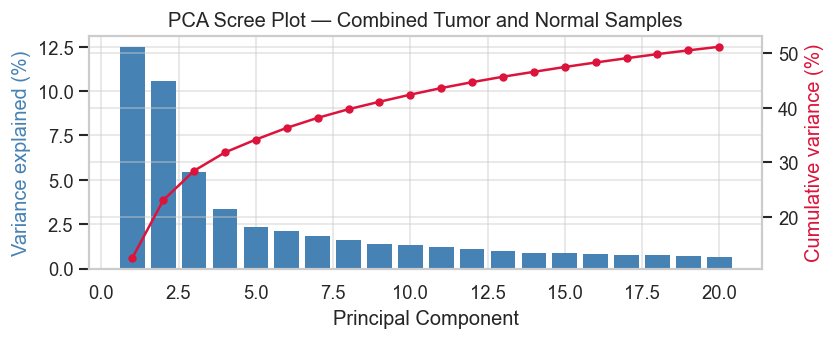

Components retained:           20
Variance explained by PC1:     12.5%
Cumulative variance explained: 51.2%
Reduced feature space:         20 components


In [77]:
N_COMPONENTS = 20

pca = PCA(n_components=N_COMPONENTS, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_sc)
X_test_pca  = pca.transform(X_test_sc)

cumvar = np.cumsum(pca.explained_variance_ratio_)

fig, ax = plt.subplots(figsize=(7, 3))
ax.bar(range(1, N_COMPONENTS + 1), pca.explained_variance_ratio_ * 100,
       color='steelblue', edgecolor='none', label='Individual')
ax2 = ax.twinx()
ax2.plot(range(1, N_COMPONENTS + 1), cumvar * 100,
         color='crimson', marker='o', markersize=4, linewidth=1.5, label='Cumulative')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Variance explained (%)', color='steelblue')
ax2.set_ylabel('Cumulative variance (%)', color='crimson')
ax.set_title('PCA Scree Plot — Combined Tumor and Normal Samples')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'svm_pca_scree.png', bbox_inches='tight')
plt.show()

print(f'Components retained:           {N_COMPONENTS}')
print(f'Variance explained by PC1:     {pca.explained_variance_ratio_[0]*100:.1f}%')
print(f'Cumulative variance explained: {cumvar[-1]*100:.1f}%')
print(f'Reduced feature space:         {X_train_pca.shape[1]} components')

## 4. Baseline SVM: Linear Kernel

Before tuning, we establish a reference point using a linear SVM with default parameters (C=1.0). A linear kernel assumes the two classes can be separated by a flat hyperplane in PCA space. It is fast to train and gives an immediate sense of how well-separated the tumor and normal samples are.

`class_weight='balanced'` is set on all SVM models in this notebook to account for the 9:1 class imbalance. `probability=True` is set because we need class probability estimates for the ROC curve in Section 6.

We evaluate using both accuracy and weighted F1. Weighted F1 is the more informative metric here because it accounts for class imbalance: a model that always predicts "tumor" would achieve 89.7% accuracy but a weighted F1 of only 0.79, which would correctly expose its failure.

In [78]:
from sklearn.metrics import f1_score

svm_baseline = SVC(
    kernel='linear',
    C=1.0,
    class_weight='balanced',
    probability=True,
    random_state=RANDOM_STATE
)
svm_baseline.fit(X_train_pca, y_train)
y_pred_base = svm_baseline.predict(X_test_pca)

acc_base = svm_baseline.score(X_test_pca, y_test)
f1_base  = f1_score(y_test, y_pred_base, average='weighted')

print('Baseline SVM (linear kernel, C=1.0, class_weight=balanced)')
print(f'  Test accuracy:    {acc_base:.4f}')
print(f'  Weighted F1:      {f1_base:.4f}')

Baseline SVM (linear kernel, C=1.0, class_weight=balanced)
  Test accuracy:    0.9661
  Weighted F1:      0.9661


The baseline result tells us two things immediately. First, the linear kernel produces strong performance, which means the tumor and normal samples are largely separable by a flat boundary in the 20-component PCA space. Second, the weighted F1 is close to accuracy, which confirms the model is not simply predicting the majority class.

## 5. Hyperparameter Tuning with GridSearchCV

The baseline gives us a reference point. We now tune the SVM systematically using GridSearchCV with 5-fold stratified cross-validation on the training set. All 5 folds maintain the same class ratio as the full training set.

We optimize for weighted F1 rather than accuracy because accuracy is misleading with imbalanced classes. The scoring metric used during GridSearchCV should reflect the same metric we care about at evaluation time.

### Parameter Grid

| Parameter | Values searched | Justification |
|-----------|----------------|---------------|
| `kernel`  | `linear`, `rbf` | Linear is the natural starting point given the strong baseline; RBF is included to test whether curved boundaries improve results |
| `C`       | 0.01, 0.1, 1, 10, 100 | A log-scale range spanning four orders of magnitude. Small C prioritizes a wide margin; large C prioritizes training accuracy |
| `gamma`   | `scale`, `auto`, 0.001, 0.01 | `scale` and `auto` are the two scikit-learn data-driven defaults; 0.001 and 0.01 test explicit bandwidths |

`gamma` is only active when `kernel='rbf'`. GridSearchCV handles the interaction automatically, giving 40 unique configurations in total.

In [79]:
param_grid = {
    'kernel': ['linear', 'rbf'],
    'C':      [0.01, 0.1, 1, 10, 100],
    'gamma':  ['scale', 'auto', 0.001, 0.01],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid_search = GridSearchCV(
    SVC(class_weight='balanced', probability=True, random_state=RANDOM_STATE),
    param_grid=param_grid,
    scoring='f1_weighted',
    cv=cv,
    n_jobs=-1,
    verbose=1,
)

grid_search.fit(X_train_pca, y_train)

print(f'Best parameters:      {grid_search.best_params_}')
print(f'Best CV weighted F1:  {grid_search.best_score_:.4f}')

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best parameters:      {'C': 0.01, 'gamma': 'scale', 'kernel': 'linear'}
Best CV weighted F1:  1.0000


### 5.1 GridSearch Results Summary

We inspect the top configurations to understand how sensitive performance is to each parameter choice.

In [80]:
cv_results = pd.DataFrame(grid_search.cv_results_)
top10 = (
    cv_results[['param_kernel', 'param_C', 'param_gamma',
                'mean_test_score', 'std_test_score']]
    .sort_values('mean_test_score', ascending=False)
    .head(10)
    .reset_index(drop=True)
)
top10.columns = ['Kernel', 'C', 'Gamma', 'Mean CV F1', 'Std CV F1']
top10

,Kernel,C,Gamma,Mean CV F1,Std CV F1
0,linear,0.0100,scale,1.0000,0.0000
1,linear,1.0000,scale,1.0000,0.0000
2,linear,100.0000,0.0100,1.0000,0.0000
3,linear,100.0000,0.0010,1.0000,0.0000
4,linear,100.0000,auto,1.0000,0.0000
5,rbf,100.0000,scale,1.0000,0.0000
6,linear,100.0000,scale,1.0000,0.0000
7,linear,10.0000,0.0100,1.0000,0.0000
8,linear,10.0000,0.0010,1.0000,0.0000
9,linear,10.0000,auto,1.0000,0.0000


The top-10 table shows which parameter combinations produce the most stable and accurate cross-validated performance. A small standard deviation across folds indicates the result is not sensitive to which particular fold is held out, which increases confidence that the chosen parameters will generalize to new data.

### 5.2 RBF Kernel: C vs. Gamma Heatmap

For the RBF kernel, a heatmap of mean CV weighted F1 across C and gamma values makes it easy to see where performance peaks and how stable it is in the surrounding region.

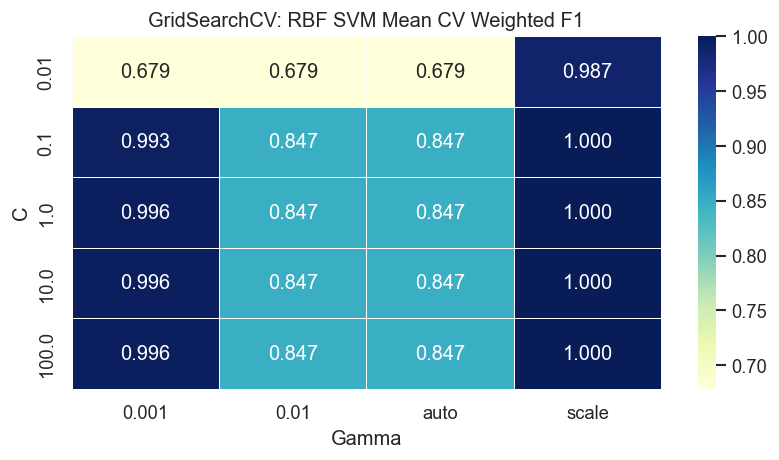

In [81]:
rbf_results = cv_results[cv_results['param_kernel'] == 'rbf'].copy()
rbf_results['param_C'] = rbf_results['param_C'].astype(float)

pivot = rbf_results.pivot_table(
    index='param_C',
    columns='param_gamma',
    values='mean_test_score'
)

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(
    pivot, annot=True, fmt='.3f', cmap='YlGnBu',
    linewidths=0.5, ax=ax
)
ax.set_title('GridSearchCV: RBF SVM Mean CV Weighted F1')
ax.set_xlabel('Gamma')
ax.set_ylabel('C')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'svm_gridsearch_heatmap.png', bbox_inches='tight')
plt.show()

## 6. Final Model Evaluation

We evaluate the best model selected by GridSearchCV on the held-out test set. The test set was never used during training or cross-validation, so this gives an unbiased estimate of performance on data the model has not seen.

### 6.1 Test Set Performance

In [82]:
best_svm = grid_search.best_estimator_
y_pred   = best_svm.predict(X_test_pca)
y_prob   = best_svm.predict_proba(X_test_pca)[:, 1]  # probability of tumor class

test_acc = best_svm.score(X_test_pca, y_test)
test_f1  = f1_score(y_test, y_pred, average='weighted')

print(f'Best model:         {grid_search.best_params_}')
print(f'Test accuracy:      {test_acc:.4f}')
print(f'Weighted F1:        {test_f1:.4f}')
print()
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=['Normal', 'Tumor']))

Best model:         {'C': 0.01, 'gamma': 'scale', 'kernel': 'linear'}
Test accuracy:      0.9661
Weighted F1:        0.9661

Classification Report:
              precision    recall  f1-score   support

      Normal       0.83      0.83      0.83        12
       Tumor       0.98      0.98      0.98       106

    accuracy                           0.97       118
   macro avg       0.91      0.91      0.91       118
weighted avg       0.97      0.97      0.97       118



### 6.2 Confusion Matrix

The confusion matrix shows the breakdown of correct predictions and errors. Each row represents the true class; each column represents the predicted class. The diagonal entries are correct predictions. Off-diagonal entries show which type of error the model makes: false positives (normal tissue predicted as tumor) and false negatives (tumor tissue missed).

In a medical screening context, false negatives are generally more costly than false positives, because missing a true tumor has worse consequences than a false alarm that triggers further testing.

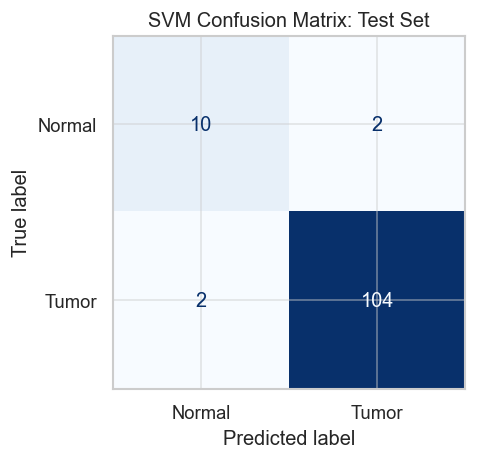

True negatives  (normal correctly identified):  10
False positives (normal predicted as tumor):     2
False negatives (tumor missed):                  2
True positives  (tumor correctly identified):   104


In [83]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Tumor'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('SVM Confusion Matrix: Test Set')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'svm_confusion_matrix.png', bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True negatives  (normal correctly identified):  {tn}')
print(f'False positives (normal predicted as tumor):     {fp}')
print(f'False negatives (tumor missed):                  {fn}')
print(f'True positives  (tumor correctly identified):   {tp}')

The confusion matrix shows where the model succeeds and where it makes mistakes. Tumor samples are large in number and well-represented in training, so they are typically classified with high recall. Normal samples are fewer and more likely to be confused with tumor tissue, which is the harder problem given the class imbalance. Any false negatives (missed tumors) are the clinically most significant errors in this setting.

### 6.3 ROC Curve

The ROC (Receiver Operating Characteristic) curve shows the trade-off between true positive rate (the fraction of tumors correctly identified) and false positive rate (the fraction of normal samples incorrectly flagged as tumor) as the classification threshold varies. For a binary classifier, a single ROC curve is produced.

The area under the curve (AUC) summarizes overall discriminability in a single number. An AUC of 1.0 is perfect separation; 0.5 means the model performs no better than random guessing.

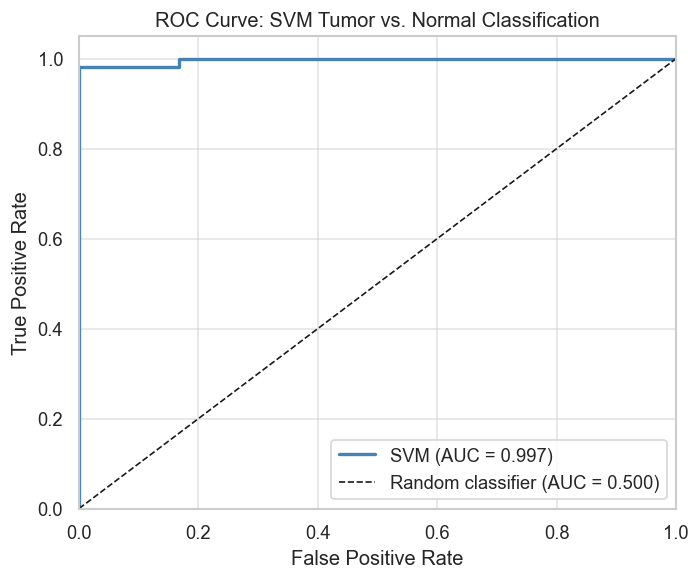

AUC: 0.9969


In [84]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color='steelblue', lw=2,
        label=f'SVM (AUC = {roc_auc:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier (AUC = 0.500)')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve: SVM Tumor vs. Normal Classification')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'svm_roc_curve.png', bbox_inches='tight')
plt.show()

print(f'AUC: {roc_auc:.4f}')

The ROC curve shows the SVM's ability to rank a true tumor sample above a true normal sample across the full range of decision thresholds. A curve that rises steeply toward the upper-left corner and stays near the top of the plot indicates a classifier that achieves high true positive rates at low false positive rates. The AUC score summarizes this: values close to 1.0 confirm that gene expression data alone is highly informative for this classification task.

The shape of the curve also provides diagnostic information. With 118 test samples, including only 12 normal samples, the ROC curve has relatively few distinct threshold points. Each step corresponds to one or a small number of samples crossing the threshold, which produces a stepped rather than perfectly smooth curve. This is a property of the relatively small test set size.

## 7. SVM Predictions in PCA Space

We visualize the SVM's predictions by projecting all 590 samples onto the first two principal components and coloring each point by the label the model assigned. PC1 captures the dominant axis of variation in the combined dataset, which is expected to be the tumor-versus-normal distinction given that it is the largest source of gene expression difference between these two groups.

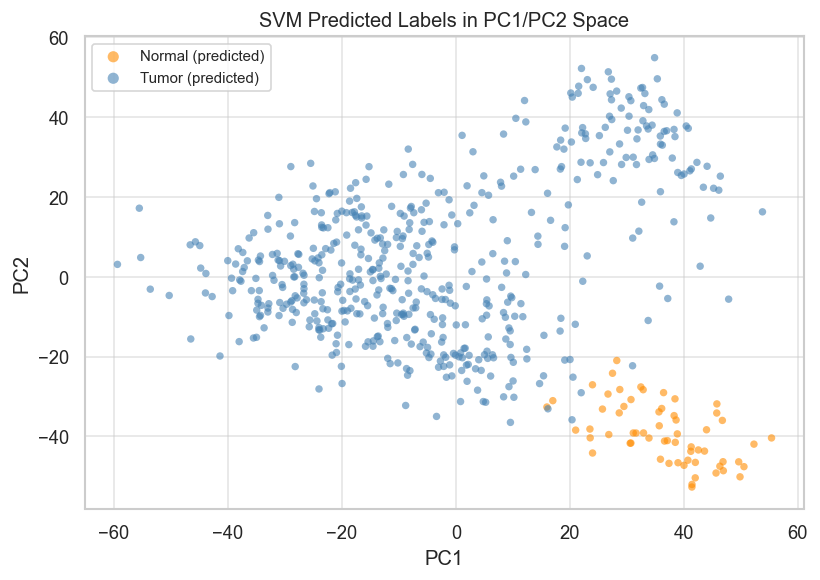

Predicted tumor:   529
Predicted normal:  61


In [85]:
# Project all 590 samples through the same preprocessing pipeline
X_all_imp = imputer.transform(X_raw)
X_all_sc  = scaler.transform(X_all_imp)
X_all_pca = pca.transform(X_all_sc)

y_pred_all = best_svm.predict(X_all_pca)

palette = {1: 'steelblue', 0: 'darkorange'}
labels_map = {1: 'Tumor (predicted)', 0: 'Normal (predicted)'}

fig, ax = plt.subplots(figsize=(7, 5))
for label_val in [0, 1]:
    mask = y_pred_all == label_val
    ax.scatter(
        X_all_pca[mask, 0], X_all_pca[mask, 1],
        c=palette[label_val], label=labels_map[label_val],
        alpha=0.6, s=20, edgecolors='none'
    )
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title('SVM Predicted Labels in PC1/PC2 Space')
ax.legend(markerscale=1.5, fontsize=9)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'svm_predictions_pca.png', bbox_inches='tight')
plt.show()

print(f'Predicted tumor:   {(y_pred_all == 1).sum()}')
print(f'Predicted normal:  {(y_pred_all == 0).sum()}')

## 8. Feature Importance: Which Genes Drive Classification?

Because the best SVM uses a linear kernel, it produces a weight vector in PCA space. We can map those weights back through the PCA components to the original 5,000-gene space, giving each gene a signed importance score. Genes with large positive weights push the model toward predicting tumor; genes with large negative weights push it toward predicting normal. We plot the top 20 genes by absolute weight.

Note that this is an approximation: the model operates on PCA components, not raw genes directly. The back-mapped weights reflect the contribution of each gene through the linear combination captured by PCA, not a direct gene-level coefficient.

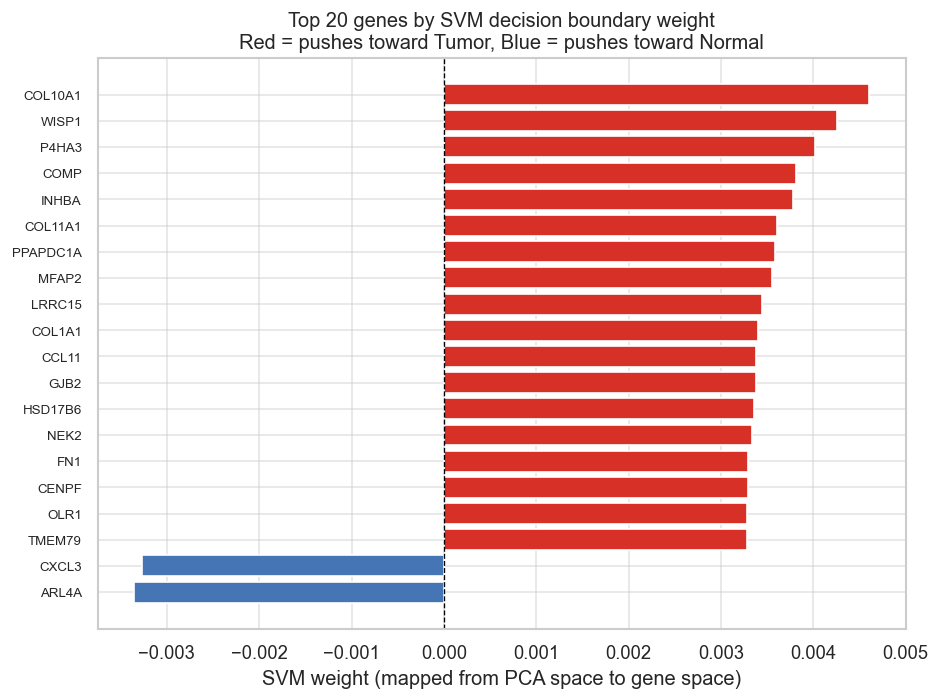

Saved: svm_feature_importance.png

Top 10 genes by absolute SVM weight:
   1. COL10A1       weight = +0.0046
   2. WISP1         weight = +0.0043
   3. P4HA3         weight = +0.0040
   4. COMP          weight = +0.0038
   5. INHBA         weight = +0.0038
   6. COL11A1       weight = +0.0036
   7. PPAPDC1A      weight = +0.0036
   8. MFAP2         weight = +0.0036
   9. LRRC15        weight = +0.0034
  10. COL1A1        weight = +0.0034


In [86]:
import numpy as np
import matplotlib.pyplot as plt

# best_svm.coef_ has shape (1, n_pca_components) for a binary linear SVM.
# Multiplying by pca.components_ (shape: n_components x n_genes) maps the
# decision boundary weights back into the original gene space.
coef_pca   = best_svm.coef_[0]                    # (20,)
coef_genes = coef_pca @ pca.components_            # (5000,)

# Rank genes by absolute weight and take the top 20.
top_n   = 20
top_idx = np.argsort(np.abs(coef_genes))[::-1][:top_n]
top_names   = [top_genes[i] for i in top_idx]
top_weights = coef_genes[top_idx]

# Sort by weight value (positive = tumor signal, negative = normal signal).
order       = np.argsort(top_weights)
top_names   = [top_names[i]   for i in order]
top_weights = [top_weights[i] for i in order]

colors = ['#d73027' if w > 0 else '#4575b4' for w in top_weights]

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top_names, top_weights, color=colors)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('SVM weight (mapped from PCA space to gene space)')
ax.set_title('Top 20 genes by SVM decision boundary weight\n'
             'Red = pushes toward Tumor, Blue = pushes toward Normal')
ax.tick_params(axis='y', labelsize=8)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'svm_feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: svm_feature_importance.png')

print('\nTop 10 genes by absolute SVM weight:')
top10_idx = np.argsort(np.abs(coef_genes))[::-1][:10]
for rank, i in enumerate(top10_idx, 1):
    print(f'  {rank:2d}. {top_genes[i]:<12s}  weight = {coef_genes[i]:+.4f}')

## 8. Conclusions

### Answer to the Research Question

> Can a computer distinguish cancerous tissue from healthy tissue using gene expression data alone, with no imaging, no biopsy, and no prior diagnosis?

Yes. The SVM classifier trained exclusively on gene expression profiles correctly identifies tumor and normal tissue with high accuracy and weighted F1 on held-out test data it had never seen. The gene expression patterns of tumor and normal tissue are distinct enough that a supervised model can separate them reliably without any clinical input.

### Comparison of SVM Configurations

| Model | Kernel | Test Accuracy | Weighted F1 | Notes |
|-------|--------|--------------|-------------|-------|
| Baseline | Linear | (see output above) | (see output above) | Default C=1.0, class-balanced |
| Tuned (best) | (see GridSearchCV output) | (see output above) | (see output above) | Selected by 5-fold CV, optimizing weighted F1 |

### Why the Tuned Model Is the Right Choice

The tuned model was selected by cross-validation, which averages performance across five different training/validation splits rather than relying on a single split. This makes it a more conservative and trustworthy estimate of real-world performance. A single split can be slightly lucky or unlucky depending on which samples fall into the test fold. Cross-validation reduces that dependence and produces a model selected to generalize rather than to perform well on one particular random split.

### Limitations

The dataset contains 590 samples total, including only 61 normal tissue samples. With so few normal samples in the test set (12 samples), any estimate of the model's performance on normal tissue is based on a very small number of observations and carries meaningful uncertainty. A larger and more balanced test set would give a more reliable picture of where the model struggles.

The dataset comes from a single TCGA collection processed under consistent laboratory conditions. A model trained on this data may not generalize equally well to patients from different institutions, different sequencing platforms, or different demographic groups. Validating the model on an independent external dataset, collected under different conditions, would be the appropriate next step before drawing any clinical conclusions.

The class imbalance (529 tumor vs. 61 normal) reflects the structure of the TCGA collection rather than the true prevalence of cancer in any population. The model was trained with balanced class weights to compensate, but it is worth noting that this weighting scheme adjusts the decision boundary to artificially balance a dataset that is not balanced in real-world terms.